# 00 — Synthetic Data Generation

**Purpose:** Generate configurable synthetic survival datasets for development,
testing, and scenario exploration.

This notebook lets you:
- Configure event rate, censoring %, and feature-target relationship
- Choose a predefined risk scenario or supply custom coefficients
- Compare multiple scenarios side-by-side
- Generate a cohort date column for temporal split (notebook 01b)

> If you don't configure anything, the default dataset is well-behaved and
> ready for the full pipeline.

---
**Outputs:** `data/raw/survival_data.parquet` (replaces whatever was there)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.synthetic_data import (
    SyntheticDataConfig,
    generate_survival_dataset,
    generate_high_churn_dataset,
    generate_low_churn_dataset,
    generate_nonlinear_dataset,
    get_dataset_summary,
)
from src.data_utils import save_data, load_config

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
print('Ready.')

Ready.


## 1. Configure Your Dataset

Edit the `SyntheticDataConfig` below to match your scenario.
**Leave it as-is for a sensible default.**

In [2]:
# ── CONFIGURATION — edit here ────────────────────────────────────────────────
config = SyntheticDataConfig(
    # Sample size
    n_samples      = 2_000,

    # Fraction of observations that are censored (e.g. 0.65 → ~35% event rate)
    censoring_pct  = 0.65,

    # How features relate to survival time: 'linear' | 'nonlinear' | 'mixed'
    # Use 'nonlinear' to test if tree models outperform Cox PH
    relationship_type = 'linear',

    # Predefined risk preset: 'balanced' | 'high_churn' | 'low_churn' | 'custom'
    risk_scenario  = 'balanced',

    # Custom coefficients — only used when risk_scenario='custom'
    # risk_coefficients = {'intercept': 1.0, 'support_calls': 0.5, ...},

    # Add cohort_date column → enables temporal split in notebook 01b
    add_cohort_date = True,
    cohort_start    = '2021-01-01',
    cohort_months   = 24,

    # Realistic messiness
    missing_pct  = 0.03,   # ~3% NaN in monthly_charges
    outlier_pct  = 0.01,   # ~1% extreme outliers in support_calls_3m

    # Noise added to the log-hazard (0 = no noise, 0.5 = noisy)
    noise_std    = 0.20,

    random_state = 42,
)
# ─────────────────────────────────────────────────────────────────────────────

print('Configuration set:')
for k, v in config.__dict__.items():
    print(f'  {k:<25}: {v}')

Configuration set:
  n_samples                : 2000
  censoring_pct            : 0.65
  relationship_type        : linear
  risk_scenario            : balanced
  risk_coefficients        : {}
  add_cohort_date          : True
  cohort_start             : 2021-01-01
  cohort_months            : 24
  missing_pct              : 0.03
  outlier_pct              : 0.01
  noise_std                : 0.2
  random_state             : 42


## 2. Generate Dataset

In [3]:
df = generate_survival_dataset(config)

summary = get_dataset_summary(df, label='configured_dataset')
print('\nDataset Summary:')
for k, v in summary.items():
    print(f'  {k:<20}: {v}')

print(f'\nShape       : {df.shape}')
print(f'Columns     : {list(df.columns)}')
df.head()


Dataset Summary:
  label               : configured_dataset
  n_samples           : 2000
  n_features          : 15
  event_rate          : 1.0
  censoring_pct       : 0.0
  duration_mean       : 2.21
  duration_median     : 1.1
  duration_p10        : 1.0
  duration_p90        : 4.5
  missing_any_pct     : 0.03

Shape       : (2000, 18)
Columns     : ['duration', 'event', 'cohort_date', 'age', 'tenure_months', 'contract_type', 'payment_method', 'monthly_charges', 'total_charges', 'num_products', 'avg_monthly_usage_3m', 'support_calls_3m', 'payment_delay_count', 'login_frequency_30d', 'charge_per_tenure', 'support_intensity', 'usage_trend', 'product_density']


,duration,event,cohort_date,age,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,avg_monthly_usage_3m,support_calls_3m,payment_delay_count,login_frequency_30d,charge_per_tenure,support_intensity,usage_trend,product_density
0,1.1000,1,2021-12-22,23.0000,63.0000,Two year,Bank transfer,60.9900,3779.3400,4.0000,55.3000,0.0000,7.0000,29.0000,0.9681,0.0000,0.3760,0.0635
1,1.0000,1,2022-05-02,62.0000,5.0000,Month-to-month,Mailed check,30.7000,173.1000,3.0000,84.8000,3.0000,6.0000,25.0000,6.1400,0.6000,6.8370,0.6000
2,1.0000,1,2021-01-31,55.0000,29.0000,Two year,Credit card,71.2300,2071.3900,2.0000,96.5000,4.0000,2.0000,21.0000,2.4562,0.1379,-3.6330,0.0690
3,1.0000,1,2021-07-30,43.0000,33.0000,One year,Electronic check,34.0800,1143.5000,3.0000,32.8000,1.0000,5.0000,16.0000,1.0327,0.0303,-0.3660,0.0909
4,2.8000,1,2022-06-09,42.0000,57.0000,Month-to-month,Mailed check,25.4900,1476.5100,5.0000,73.9000,0.0000,3.0000,25.0000,0.4472,0.0000,-2.4040,0.0877


## 3. Target Variable Inspection

/Users/ana/Documents/survival-analysis-pipelines/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


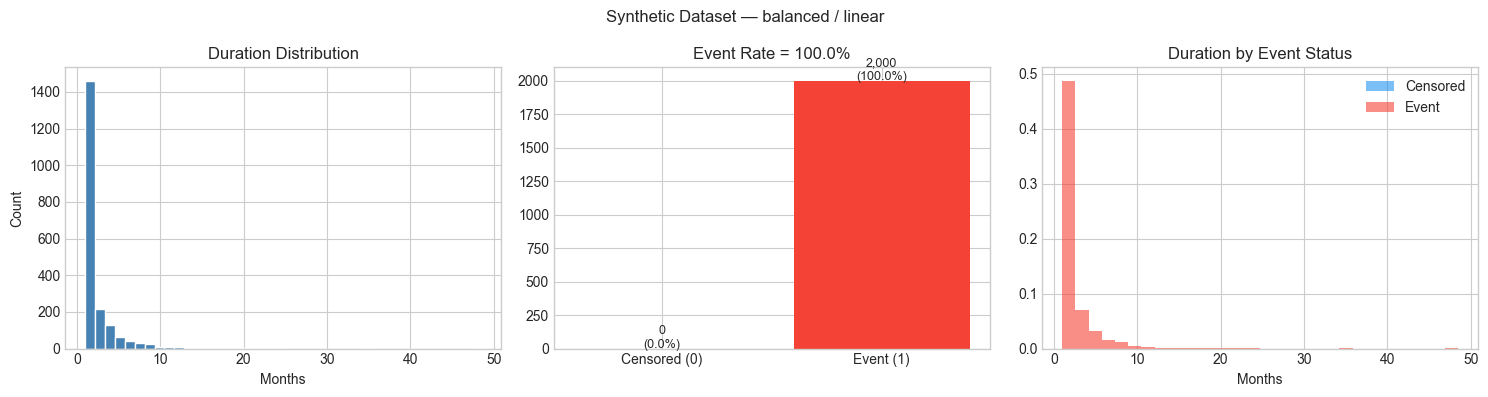

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Duration distribution
axes[0].hist(df['duration'], bins=40, color='steelblue', edgecolor='white')
axes[0].set(title='Duration Distribution', xlabel='Months', ylabel='Count')

# Event counts
counts = df['event'].value_counts()
bars = axes[1].bar(['Censored (0)', 'Event (1)'], [counts.get(0,0), counts.get(1,0)],
                   color=['#2196F3', '#F44336'])
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 5,
                 f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=9)
axes[1].set(title=f'Event Rate = {df["event"].mean():.1%}')

# Duration by event status
for s, lbl, clr in [(0,'Censored','#2196F3'), (1,'Event','#F44336')]:
    sub = df[df['event']==s]['duration']
    axes[2].hist(sub, bins=30, alpha=0.6, label=lbl, color=clr, density=True)
axes[2].set(title='Duration by Event Status', xlabel='Months')
axes[2].legend()

plt.suptitle(f"Synthetic Dataset — {config.risk_scenario} / {config.relationship_type}",
             fontsize=12)
plt.tight_layout()
plt.show()

## 4. Cohort Date Distribution (for temporal split)

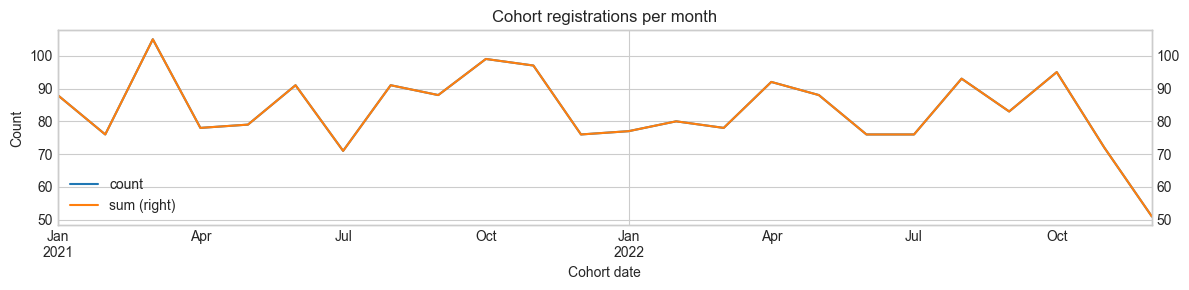

Date range: 2021-01-01 → 2022-12-20


In [5]:
if 'cohort_date' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 3))
    df.set_index('cohort_date').resample('ME')['event'].agg(['count', 'sum']).plot(
        ax=ax, secondary_y='sum'
    )
    ax.set_title('Cohort registrations per month')
    ax.set_xlabel('Cohort date')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(f'Date range: {df["cohort_date"].min().date()} → {df["cohort_date"].max().date()}')
else:
    print('cohort_date not generated (add_cohort_date=False).')

## 5. Scenario Comparison

Compare all three risk presets to understand their differences.

In [6]:
scenarios = {
    'balanced'   : generate_survival_dataset(SyntheticDataConfig(n_samples=500, random_state=42)),
    'high_churn' : generate_high_churn_dataset(n=500),
    'low_churn'  : generate_low_churn_dataset(n=500),
    'nonlinear'  : generate_nonlinear_dataset(n=500),
}

summaries = {label: get_dataset_summary(df, label) for label, df in scenarios.items()}
summary_df = pd.DataFrame(summaries).T
print('Scenario comparison:')
display(summary_df[['n_samples','event_rate','censoring_pct','duration_median','duration_p10','duration_p90']])

Scenario comparison:


,n_samples,event_rate,censoring_pct,duration_median,duration_p10,duration_p90
balanced,500,1.0000,0.0000,1.1000,1.0000,4.8100
high_churn,500,1.0000,0.0000,1.0000,1.0000,1.0000
low_churn,500,0.8500,0.1500,36.2500,10.2000,91.1300
nonlinear,500,1.0000,0.0000,1.0000,1.0000,3.8100


/Users/ana/Documents/survival-analysis-pipelines/.venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


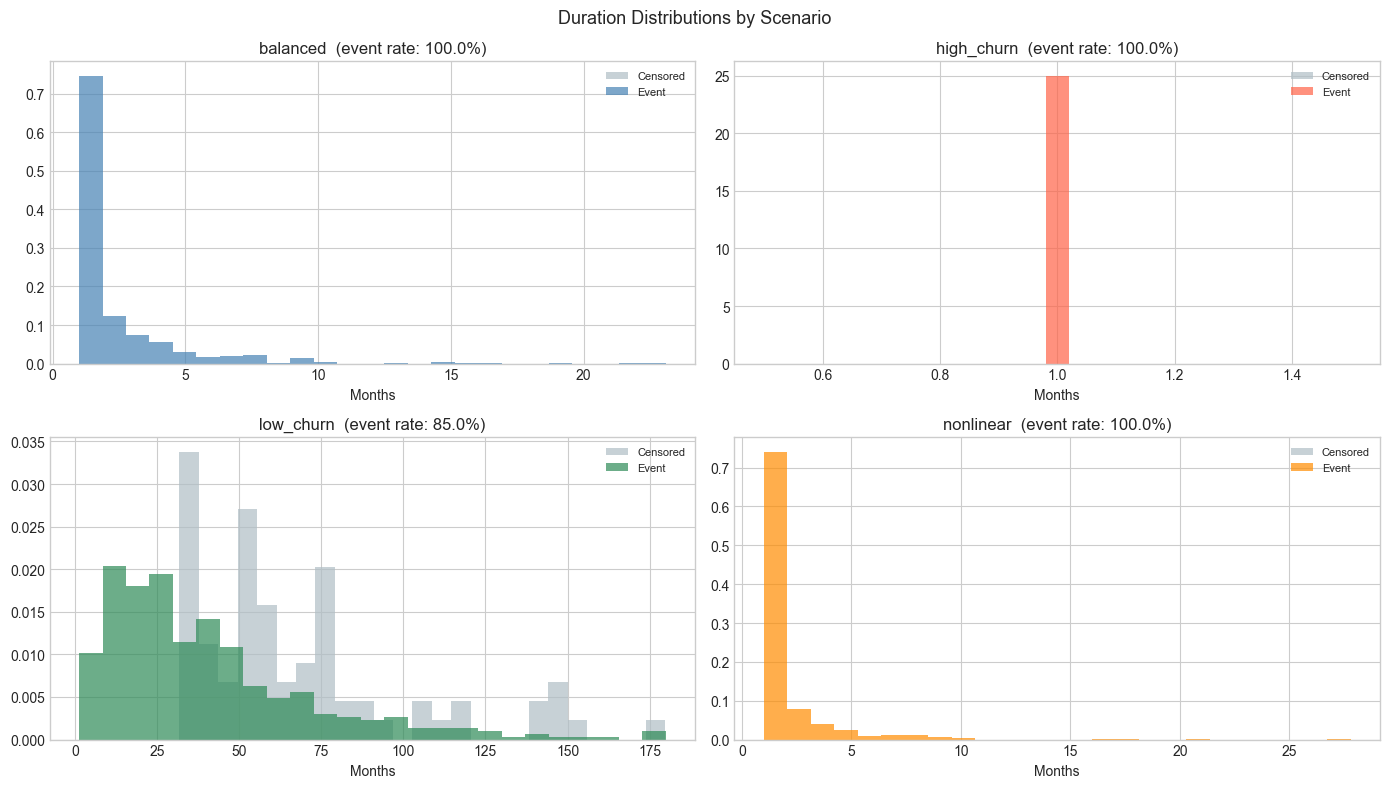

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for ax, (label, sdf), color in zip(axes.flat, scenarios.items(), colors):
    for s, lbl, clr in [(0,'Censored','#B0BEC5'), (1,'Event', color)]:
        sub = sdf[sdf['event']==s]['duration']
        ax.hist(sub, bins=25, alpha=0.7, label=lbl, color=clr, density=True)
    event_rate = sdf['event'].mean()
    ax.set_title(f"{label}  (event rate: {event_rate:.1%})")
    ax.set_xlabel('Months')
    ax.legend(fontsize=8)

plt.suptitle('Duration Distributions by Scenario', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Save Dataset

In [8]:
# Save the configured dataset (overwrites previous version)
from src.data_utils import save_data
save_data(df, name='survival_data', stage='raw')
print(f'\nSaved {len(df):,} rows.')
print('Next step: run 01_data_loading.ipynb (or skip to 02_data_quality.ipynb)')

Saved 2,000 rows → /Users/ana/Documents/survival-analysis-pipelines/data/raw/survival_data.parquet

Saved 2,000 rows.
Next step: run 01_data_loading.ipynb (or skip to 02_data_quality.ipynb)
